Датасет был взят по ссылке: https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars

Первичный анализ данных (EDA) и предобработка

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ToyotaCorolla.csv')
print(f"\nРазмер таблицы (строки, колонки): {df.shape}")
print("\n--- Техническая информация ---")
df.info()


Размер таблицы (строки, колонки): (1436, 39)

--- Техническая информация ---
<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int6

Топ признаков, влияющих на цену:
 Price              1.000000
Mfg_Year           0.885159
Boardcomputer      0.601292
Automatic_airco    0.588262
Weight             0.581198
Name: Price, dtype: float64


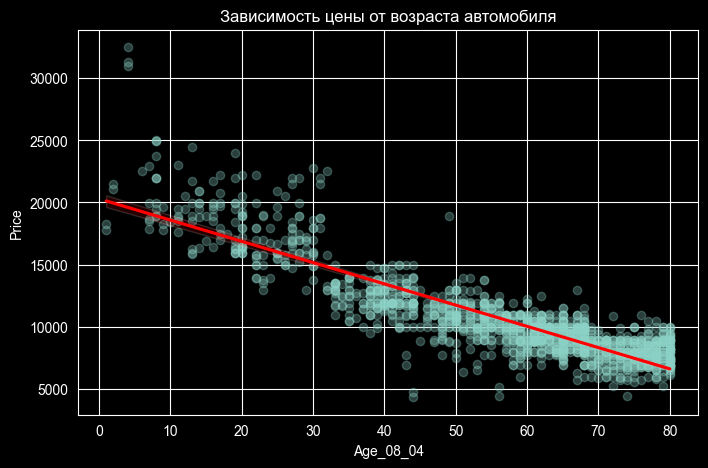

In [3]:
# 1. Удаляем неинформативные колонки (ID и текстовые названия моделей)
df_clean = df.drop(['Id', 'Model'], axis=1)

# 2. Превращаем категориальный признак Fuel_Type в числовой (OHE)
df_clean = pd.get_dummies(df_clean, columns=['Fuel_Type'], drop_first=True)

# 3. Отбор наиболее важных признаков для анализа
main_correlations = df_clean.corr(numeric_only=True)['Price'].sort_values(ascending=False)
print("Топ признаков, влияющих на цену:\n", main_correlations.head(5))

# 4. Визуализация самой сильной зависимости: Цена vs Возраст
plt.figure(figsize=(8, 5))
sns.regplot(x='Age_08_04', y='Price', data=df_clean, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Зависимость цены от возраста автомобиля')
plt.show()

Предобработка:
- Удалил Primary Key столбец и использовал OHE для преобразования типа топлива в бинарный признак
Вывод после EDA:
- Чем морщинестее изюм - тем он дешевле (с возрастом цена падает)

Работа с признаками (Feature Engineering)


In [4]:
from sklearn.preprocessing import StandardScaler
# 1. Удаление неинформативных признаков
# Дополнительно удалим Cylinders,
# так как у всех машин их 4 (нулевая вариативность не дает информации модели).
df_final = df_clean.drop(['Cylinders'], axis=1)

# 2. Создание нового признака: "Общая надежность"
safety_features = ['ABS', 'Airbag_1', 'Airbag_2', 'Central_Lock', 'Powered_Windows']
df_final['Safety_Score'] = df_final[safety_features].sum(axis=1)

# 3. Масштабирование (Standardization)
# Линейная регрессия чувствительна к разным масштабам (пробег в тысячах, возраст в десятках).
scaler = StandardScaler()
features_to_scale = ['Age_08_04', 'KM', 'HP', 'Weight', 'Quarterly_Tax']
df_final[features_to_scale] = scaler.fit_transform(df_final[features_to_scale])

print("Итоговое количество признаков:", df_final.shape[1])

Итоговое количество признаков: 38


- Как вы работали с признаками?
Я провел масштабирование числовых данных с помощью StandardScaler, чтобы признаки с большими значениями не перекрывали остальные. Создал показатель безопасности.
- Какие признаки вы добавили/изменили и почему?
Добавил показатель безопасности: чем надежнее транспорт - тем дальше уедем (больше комплектующих - больше цена)
- Какие признаки вы удалили и почему?
PK (Id), Model, Cylinders, Color: они не нужны при дальнейшей работе с датасетом, т.к либо никак на него не влияют, либо являются нумерацией

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Готовим X (все колонки, кроме цены) и y (только цена)
X = df_final.drop(['Price', 'Color'], axis=1)
y = df_final['Price']

# 2. Инициализируем тренировочные и тестовые наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Проверяем, что получилось
print(f"Обучающая выборка (X_train): {X_train.shape}")
print(f"Ответы для обучения (y_train): {y_train.shape}")
# 1. Создаем объект модели
lr = LinearRegression()

# 2. Обучаем модель на тренировочных данных
lr.fit(X_train, y_train)

# 3. Делаем предсказание на тестовых данных
y_pred = lr.predict(X_test)

# 4. Выводим коэффициенты для анализа (выберем топ-5 самых влиятельных)
coefficients = pd.DataFrame({'Признак': X.columns, 'Вес (Коэффициент)': lr.coef_})
coefficients = coefficients.sort_values(by='Вес (Коэффициент)', ascending=False)

print("Топ-5 признаков, повышающих цену:")
print(coefficients.head(5))
print("\nТоп-5 признаков, снижающих цену:")
print(coefficients.tail(5))

# 5. Считаем качество
print(f"\nТочность R^2: {r2_score(y_test, y_pred):.4f}")
print(f"Средняя ошибка (MAE): {mean_absolute_error(y_test, y_pred):.0f} евро")

Обучающая выборка (X_train): (1148, 36)
Ответы для обучения (y_train): (1148,)
Топ-5 признаков, повышающих цену:
             Признак  Вес (Коэффициент)
34  Fuel_Type_Petrol        2368.505792
19   Automatic_airco        2252.421839
2           Mfg_Year        1018.665261
11            Weight         845.306514
10     Quarterly_Tax         586.058384

Топ-5 признаков, снижающих цену:
              Признак  Вес (Коэффициент)
15                ABS        -390.672998
3                  KM        -566.567167
0           Age_08_04        -656.636494
30     Radio_cassette        -665.463619
31  Parking_Assistant       -1112.450902

Точность R^2: 0.8870
Средняя ошибка (MAE): 823 евро


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import GridSearchCV

# 1. Сначала масштабируем данные
scaler = StandardScaler()
# Обучаем scaler на X_train и трансформируем оба набора
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Настраиваем модели
param_grid = {'alpha': [0.1, 1, 10, 100]}
models = {
    'Linear': LinearRegression(),
    'Ridge': GridSearchCV(Ridge(), param_grid, cv=5),
    'Lasso': GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5)
}

# 3. Обучаем на 1 масштабированном наборе
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    r2 = r2_score(y_test, model.predict(X_test_scaled))
    print(f"{name} R2 Score: {r2:.4f}")

Linear R2 Score: 0.8870
Ridge R2 Score: 0.8966
Lasso R2 Score: 0.8888


- Как проходило обучение моделей?
1) Сначала данные были очищены от текста и масштабированы с помощью StandardScaler
2) Была обучена стандартная линейная регрессия
3) Для Ridge и Lasso обучение включало в себя GridSearchCV. (многократное с разными значениями параметра)
- Сравнение скорости обучения (расставлены по мере уменьшения скорости)
1) Linear Regression
2) Ridge и Lasso (без GridSearchCV)
3) Ridge и Lasso + GridSearchCV

Оценка качества и сравнение моделей

- Какие метрики вы использовали для сравнения моделей?
1) R^2 (Коэффициент детерминации): Нужен для общей оценки точности.
2) MAE (Средняя абсолютная ошибка)
- На какой части выборки вы считали метрики?
1) Метрики рассчитывались только на тестовой выборке
- Какая модель по итогу справилась лучше
1) Вообще все 3 довольно близки, но победитель - Ridge
- Насколько хорошие получились результаты?
1) Результаты получились выше среднего (что уже радует), т.к погрешнсоть цены ~ 800 евро при цене +-14000 за машину
- Чем докажете, что ваша модель не переобучилась?
1) Результатами R^2 при метриках на тестовой части